In [48]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime

In [25]:
df = pd.read_parquet("../data/raw_prices.parquet")

In [26]:
df.isna().sum()

Ticker  Price 
DPZ     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
                 ..
GE      Open      0
        High      0
        Low       0
        Close     0
        Volume    0
Length: 2532, dtype: int64

In [27]:
print(df.index.min())
print(df.index.max())

2023-01-03 00:00:00
2026-07-17 00:00:00


In [37]:
df.head()

Ticker             DPZ                                                   NDAQ  \
Price             Open        High         Low       Close  Volume       Open   
Date                                                                            
2023-01-03  332.334954  332.334954  315.987187  321.338562  580000  58.561135   
2023-01-04  324.956741  327.286715  321.565966  326.188049  578200  59.227363   
2023-01-05  322.977136  322.977136  317.313186  320.921814  475700  58.266096   
2023-01-06  320.865014  325.023003  317.057493  324.511536  499000  57.961538   
2023-01-09  326.765698  331.293060  315.418868  316.233429  632000  58.941838   

Ticker                                                ...         ZTS  \
Price            High        Low      Close   Volume  ...        Open   
Date                                                  ...               
2023-01-03  58.875214  58.104296  58.780037  1596000  ...  142.725505   
2023-01-04  59.636615  58.408858  58.675350  2093300  ...  143.071152   
2023-01-05  58.408856  57.219169  57.333382  1724300  ...  141.467807   
2023-01-06  58.827630  57.590353  58.675350  1536000  ...  140.738144   
2023-01-09  60.160076  58.780038  59.589027  2466400  ...  143.051919   

Ticker                                                          GE             \
Price             High         Low       Close   Volume       Open       High   
Date                                                                            
2023-01-03  142.850305  139.413232  140.987762  1840600  51.431826  52.068222   
2023-01-04  144.789689  142.053470  143.013550  1796100  53.624464  55.027592   
2023-01-05  142.264661  138.510759  139.643646  1560900  54.792434  56.085820   
2023-01-06  142.687106  135.870545  141.746231  1761200  56.446396  56.697234   
2023-01-09  143.551165  141.131759  141.189362  1700500  56.438556  57.935745   

Ticker                                      
Price             Low      Close    Volume  
Date                                        
2023-01-03  51.119748  52.000912  10280781  
2023-01-04  52.323245  55.027592  21031104  
2023-01-05  54.086952  55.882011  16001061  
2023-01-06  55.458720  56.391525  13018044  
2023-01-09  56.407203  56.963749   9488844  

[5 rows x 2532 columns]

In [39]:
tickers = ['SPY','GOOG', 'NVDA', 'NFLX', 'MSFT']
df[tickers]

Ticker             SPY                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2023-01-03  367.528413  369.498150  361.274962  364.133972   74850700   
2023-01-04  366.390465  368.972173  363.349808  366.945068   85934100   
2023-01-05  364.994486  365.109223  362.164190  362.757019   76970500   
2023-01-06  365.845539  372.194615  362.785768  371.075867  104189600   
2023-01-09  373.265479  376.449587  370.683800  370.865448   73978100   
...                ...         ...         ...         ...        ...   
2026-07-13  752.469971  753.909973  748.000000  749.169983   44013600   
2026-07-14  750.909973  753.340027  748.659973  751.830017   35143100   
2026-07-15  754.239990  755.580017  750.200012  754.809998   43844800   
2026-07-16  752.760010  754.570007  747.880005  750.719971   46409800   
2026-07-17  742.080017  747.289978  740.799988  743.289978   62569200   

Ticker            GOOG                                                ...  \
Price             Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2023-01-03   89.044922   90.749892   88.241996   88.916054  20738500  ...   
2023-01-04   90.214602   90.442587   87.032657   87.934700  27046500  ...   
2023-01-05   87.300299   87.439075   85.803494   86.011658  23136100  ...   
2023-01-06   86.596500   87.696799   84.822143   87.389511  26612600  ...   
2023-01-09   88.415455   90.036168   87.805832   88.023911  22996700  ...   
...                ...         ...         ...         ...       ...  ...   
2026-07-13  353.989990  355.750000  349.820007  350.670013  10583500  ...   
2026-07-14  348.839996  357.880005  348.839996  357.329987  11252600  ...   
2026-07-15  356.010010  372.140015  355.670013  370.209991  20258200  ...   
2026-07-16  372.170013  374.350006  351.670013  353.809998  23603700  ...   
2026-07-17  345.769989  348.170013  341.125000  346.119995  21991900  ...   

Ticker           NFLX                                                    MSFT  \
Price            Open       High        Low      Close     Volume        Open   
Date                                                                            
2023-01-03  29.806000  29.839001  28.870001  29.495001   67640000  236.351359   
2023-01-04  29.823999  31.114000  29.551001  30.941000   93451000  225.850346   
2023-01-05  30.700001  31.417999  30.455000  30.969999   83284000  220.910968   
2023-01-06  31.157000  31.677000  30.368999  31.555000   89598000  216.827212   
2023-01-09  31.683001  32.169998  31.322001  31.517000   67666000  220.181723   
...               ...        ...        ...        ...        ...         ...   
2026-07-13  73.900002  75.449997  73.709999  73.830002   35101800  387.750000   
2026-07-14  72.639999  74.010002  72.279999  73.529999   33312100  382.820007   
2026-07-15  73.790001  75.059998  73.129997  73.680000   32854300  387.799988   
2026-07-16  73.949997  74.680000  72.940002  74.349998   77505200  398.309998   
2026-07-17  65.480003  69.489998  65.080002  68.949997  141918400  394.859985   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2023-01-03  238.947450  230.828579  232.948242  25740000  
2023-01-04  226.424010  219.705295  222.758377  50623400  
2023-01-05  221.251285  215.621548  216.156326  39585600  
2023-01-06  219.510808  213.278252  218.703781  43613600  
2023-01-09  224.839142  220.142837  220.833176  27369800  
...                ...         ...         ...       ...  
2026-07-13  393.649994  384.149994  390.989990  28914900  
2026-07-14  388.190002  378.649994  384.929993  27863900  
2026-07-15  398.959991  386.399994  395.630005  36253700  
2026-07-16  405.989990  392.049988  401.100006  3704740

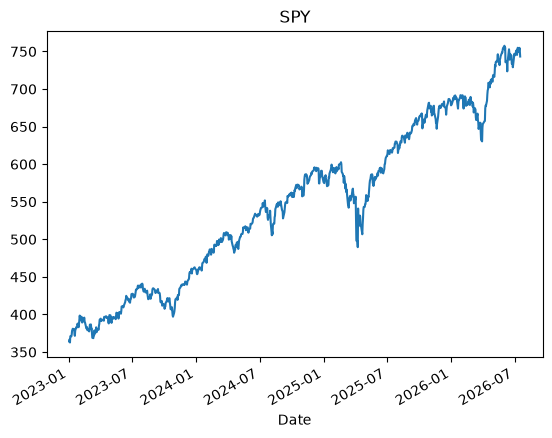

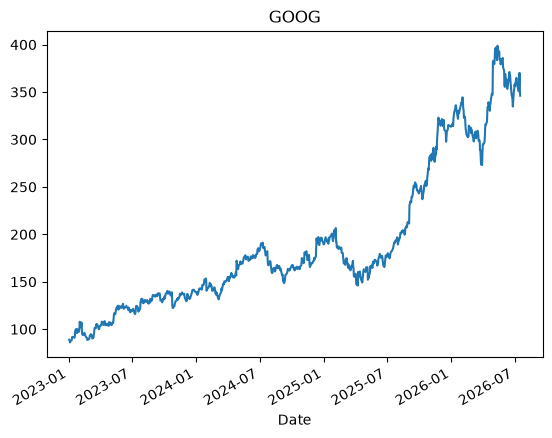

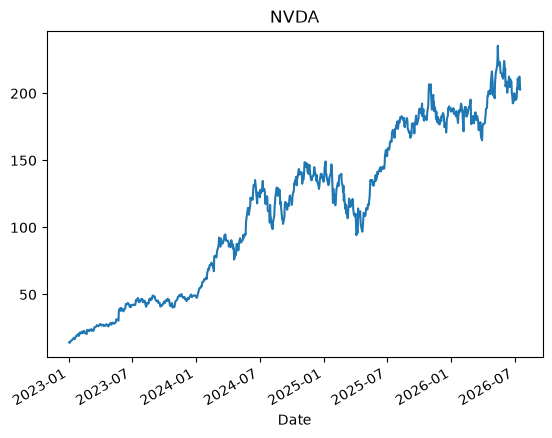

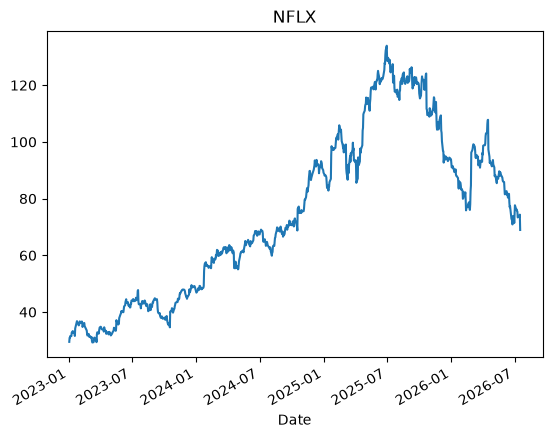

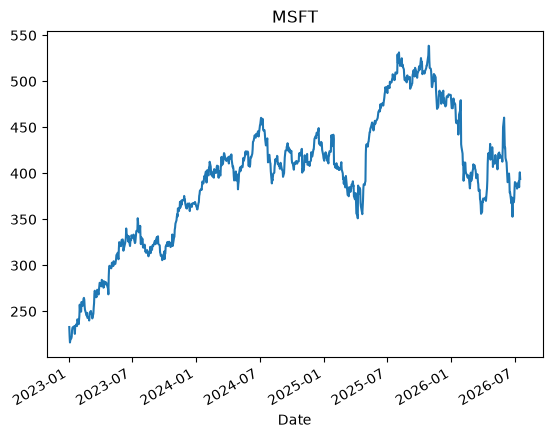

In [40]:
for t in tickers:
    df[t]["Close"].plot(title=t)
    plt.show()

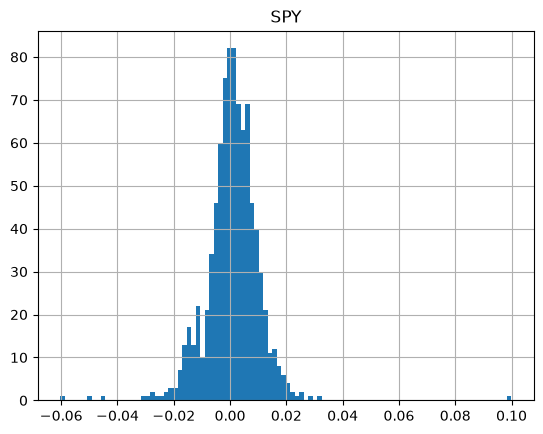

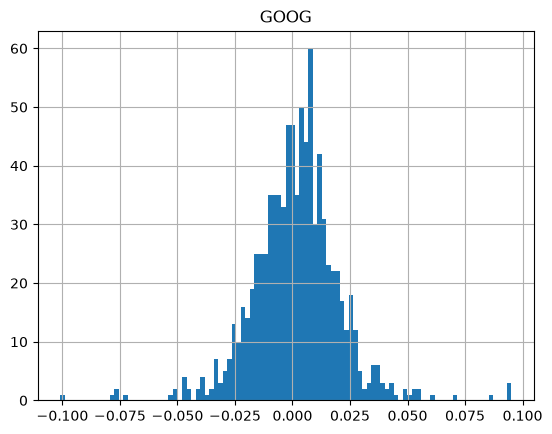

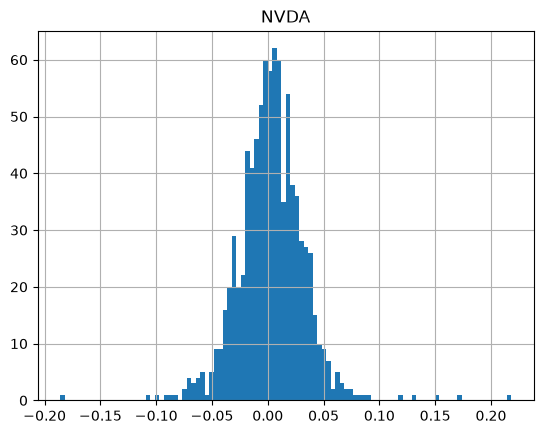

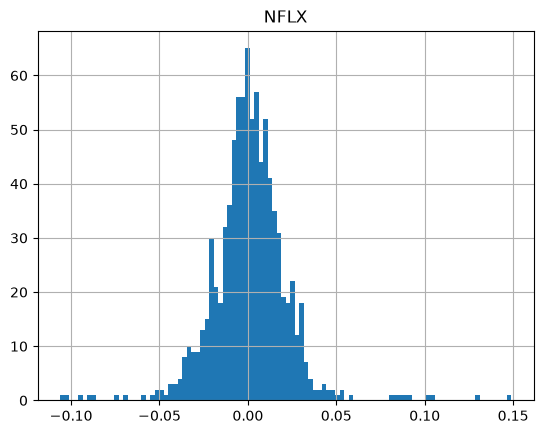

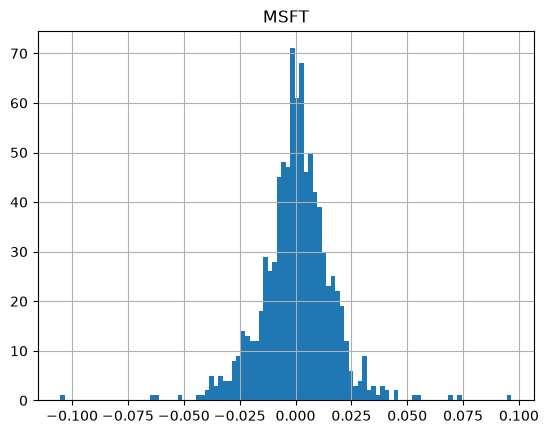

In [41]:
for t in tickers:
    log_returns = np.log(df[t]['Close'] / df[t]['Close'].shift(1))
    log_returns.hist(bins=100)
    plt.title(t)
    plt.show()


In [42]:
# Check if fat tails are genuine fat tails or not
for t in tickers:
    log_returns = np.log(df[t]['Close'] / df[t]['Close'].shift(1))
    df[(t, 'Log Return')] = log_returns    
    print(t, log_returns.idxmax(), log_returns.max())

SPY 2025-04-09 00:00:00 0.09986287145801089
GOOG 2026-04-30 00:00:00 0.09504574953029267
NVDA 2023-05-25 00:00:00 0.21808788499071996
NFLX 2023-10-19 00:00:00 0.1488919969456922
MSFT 2025-04-09 00:00:00 0.0965247676057286


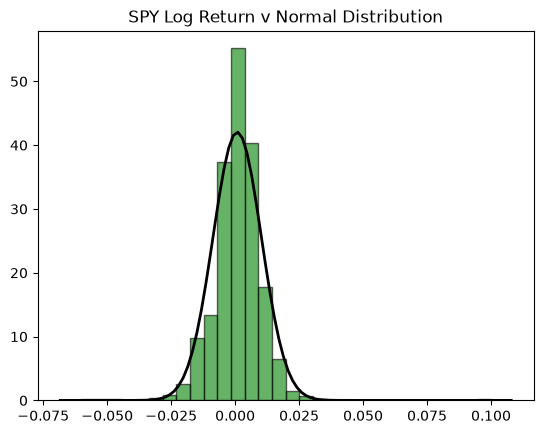

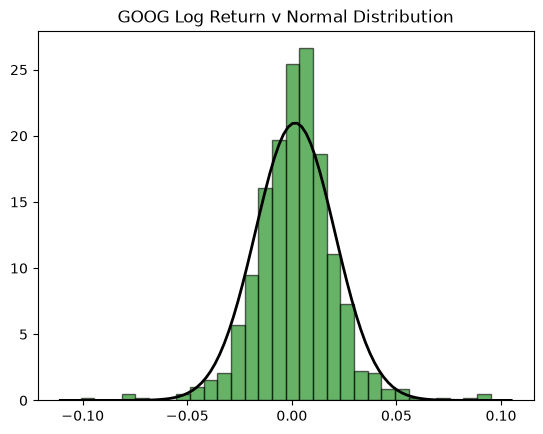

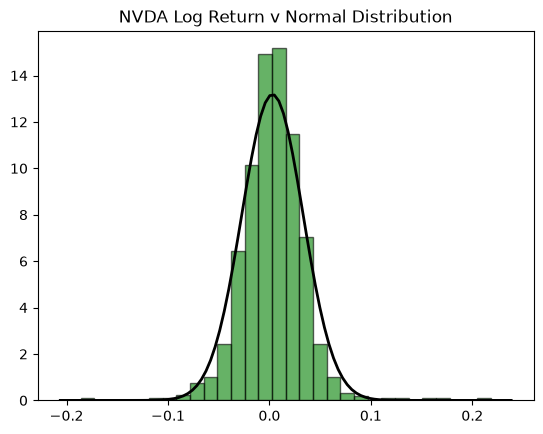

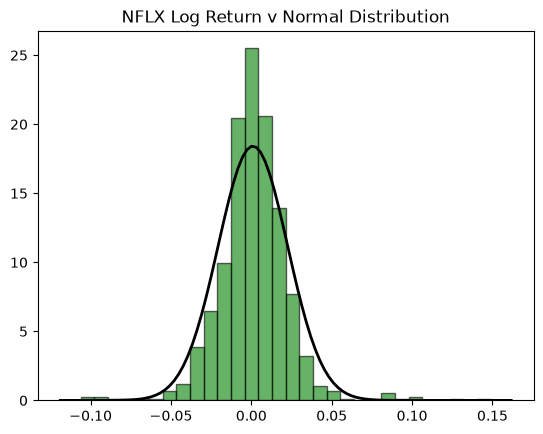

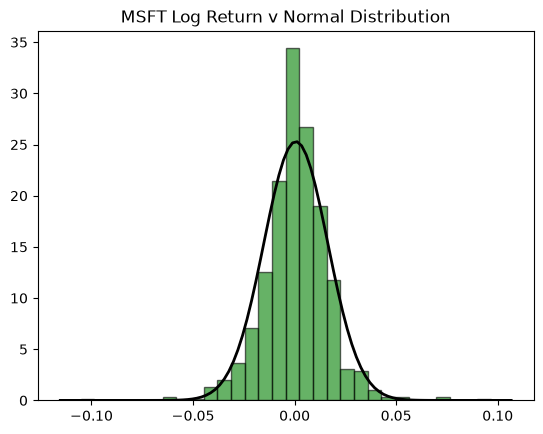

In [51]:
for t in tickers:
    clean_returns = df[(t, 'Log Return')].dropna()

    plt.figure()
    plt.hist(clean_returns, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')
    
    mu, std = norm.fit(clean_returns)
    xmin, xmax = plt.xlim()

    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    plt.plot(x, p, 'k', linewidth=2)
    plt.title(f'{t} Log Return v Normal Distribution')

    plt.show()
    

In [53]:
df.head()

Ticker             DPZ                                                   NDAQ  \
Price             Open        High         Low       Close  Volume       Open   
Date                                                                            
2023-01-03  332.334954  332.334954  315.987187  321.338562  580000  58.561135   
2023-01-04  324.956741  327.286715  321.565966  326.188049  578200  59.227363   
2023-01-05  322.977136  322.977136  317.313186  320.921814  475700  58.266096   
2023-01-06  320.865014  325.023003  317.057493  324.511536  499000  57.961538   
2023-01-09  326.765698  331.293060  315.418868  316.233429  632000  58.941838   

Ticker                                                ...         GE  \
Price            High        Low      Close   Volume  ...       Open   
Date                                                  ...              
2023-01-03  58.875214  58.104296  58.780037  1596000  ...  51.431826   
2023-01-04  59.636615  58.408858  58.675350  2093300  ...  53.624464   
2023-01-05  58.408856  57.219169  57.333382  1724300  ...  54.792434   
2023-01-06  58.827630  57.590353  58.675350  1536000  ...  56.446396   
2023-01-09  60.160076  58.780038  59.589027  2466400  ...  56.438556   

Ticker                                                       SPY       GOOG  \
Price            High        Low      Close    Volume Log Return Log Return   
Date                                                                          
2023-01-03  52.068222  51.119748  52.000912  10280781        NaN        NaN   
2023-01-04  55.027592  52.323245  55.027592  21031104   0.007690  -0.011098   
2023-01-05  56.085820  54.086952  55.882011  16001061  -0.011479  -0.022112   
2023-01-06  56.697234  55.458720  56.391525  13018044   0.022673   0.015892   
2023-01-09  57.935745  56.407203  56.963749   9488844  -0.000567   0.007233   

Ticker           NVDA       NFLX       MSFT  
Price      Log Return Log Return Log Return  
Date                                         
2023-01-03        NaN        NaN        NaN  
2023-01-04   0.029867   0.047861  -0.044729  
2023-01-05  -0.033366   0.000937  -0.030086  
2023-01-06   0.040797   0.018713   0.011716  
2023-01-09   0.050458  -0.001205   0.009689  

[5 rows x 2537 columns]

In [62]:
def calc_volatility(windowsize):
    for t in tickers:
        df[(t, 'Volatility')] = df[(t, 'Log Return')].rolling(window=windowsize, min_periods=1).std() * np.sqrt(252)
    
calc_volatility(20)

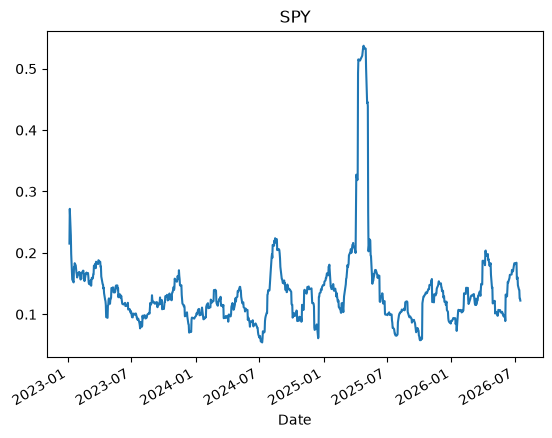

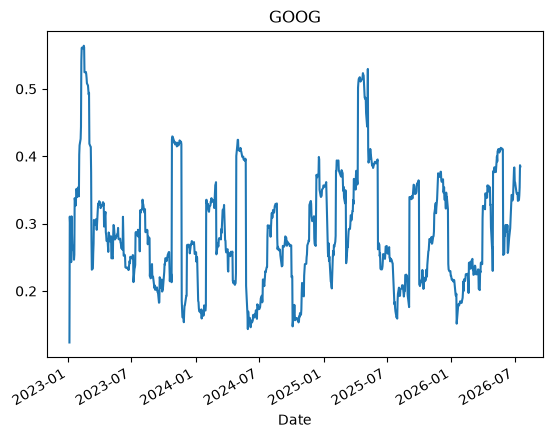

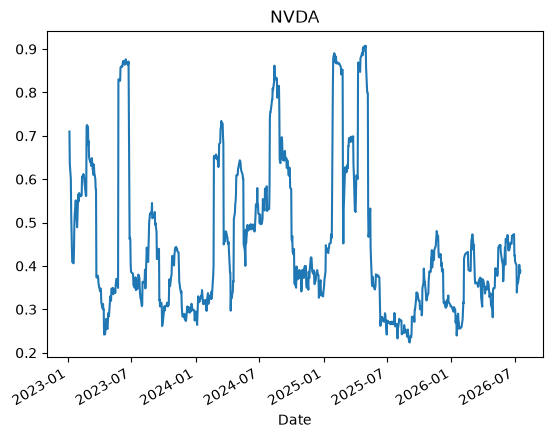

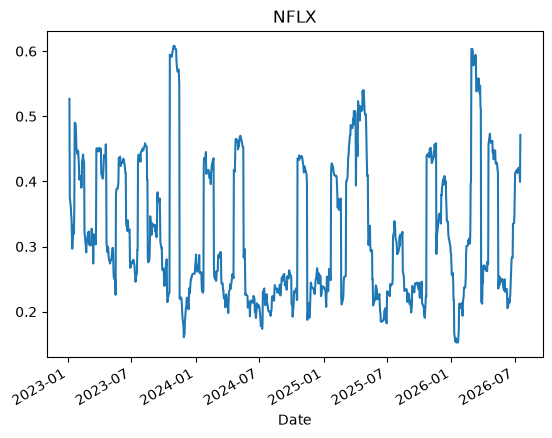

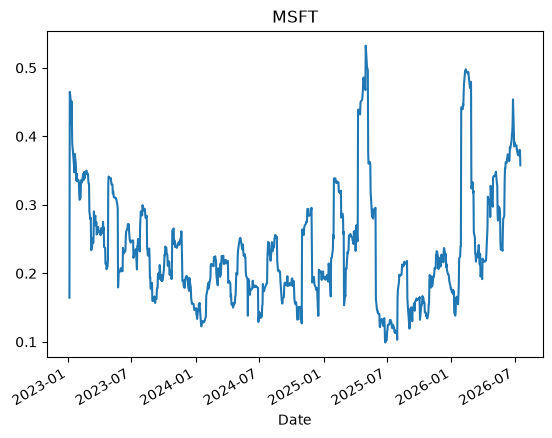

In [64]:
for t in tickers:
    df[(t, 'Volatility')].plot()
    plt.title(t)
    plt.show()


In [84]:
def calc_autocorr_all(tickers, lags):
    results = {}
    for t in tickers:
        log_returns = df[(t, "Log Return")].dropna()
        results[t] = [log_returns.autocorr(lag=k) for k in lags]
    return pd.DataFrame(results, index=lags)

In [88]:
lags = range(1, 31) 
raw_acf_df = calc_autocorr_all(tickers, lags)
raw_acf_df.head()

,SPY,GOOG,NVDA,NFLX,MSFT
1,-0.055820,0.014645,-0.061469,0.027598,0.015108
2,0.026680,-0.005618,0.034605,0.013876,-0.057400
3,-0.080227,-0.034504,-0.080958,0.010014,0.004405
4,-0.048886,-0.034227,-0.026865,0.019602,-0.018861
5,-0.000296,-0.028912,0.003883,0.020572,0.026120


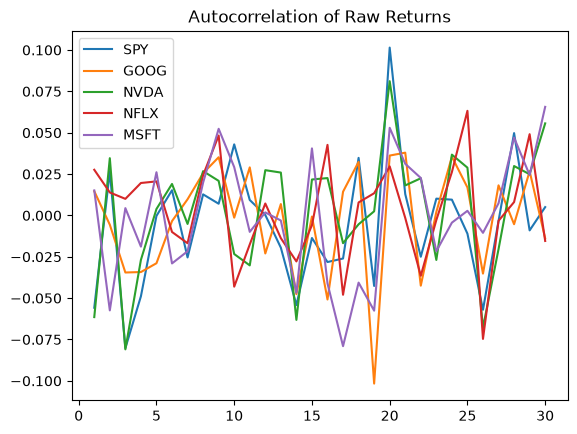

In [89]:
raw_acf_df.plot()
plt.title("Autocorrelation of Raw Returns")
plt.show()


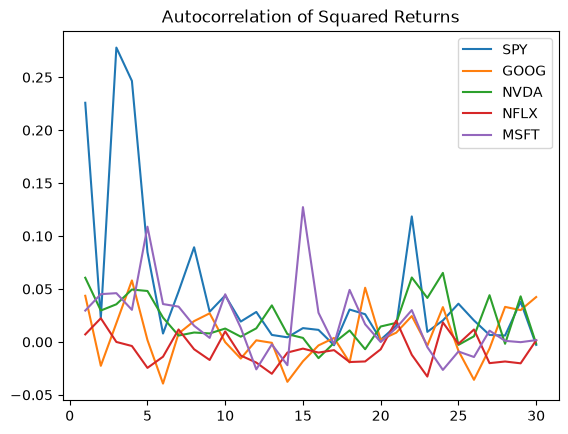

In [91]:
def calc_autocorr_squared(tickers, lags):
    results = {}
    for t in tickers:
        log_returns = df[(t, "Log Return")].dropna()
        results[t] = [(log_returns**2).autocorr(lag=k) for k in lags]
    return pd.DataFrame(results, index=lags)

squared_acf_df = calc_autocorr_squared(tickers, lags)
squared_acf_df.plot()
plt.title("Autocorrelation of Squared Returns")
plt.show()

# Writeup
There isn't anything wrong with the data. There aren't any missing values and the ticker prices look reasonable. There were a few outliers with the fat tails, but those coincided with actual market events, which I verified by checking dates. 
I also checked volatility and something I noticed as a spike in July 2025. This is likely due to things like tariffs, slowed down job grwoth, and federal policy changes during that time.
I also looked over autocorrelation and squared autocorrelation. Something I noticed with this is that with autocorrelation, most tickers have high correlation around 20 lags, but for squared autocorrelation, its scattered, and for SPY it peaks at around 3.


